# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Sleep Mobile Stress Dataset](https://www.kaggle.com/datasets/jayjoshi37/sleep-screen-time-and-stress-analysis)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

/kaggle/input/datasets/jayjoshi37/sleep-screen-time-and-stress-analysis/sleep_mobile_stress_dataset_15000.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('sleep_mobile_stress_dataset_15000.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
0,1,56,Female,Designer,3.26,86,5.31,7.72,3.49,0,35,119,3.57
1,2,46,Female,Teacher,1.85,32,7.36,9.70,3.01,0,16,299,1.91
2,3,32,Female,Designer,3.04,107,4.50,6.38,5.03,0,17,21,6.05
3,4,25,Male,Software Engineer,9.00,36,6.68,5.53,10.00,0,3,220,9.92
4,5,38,Female,Teacher,3.52,56,7.57,6.69,6.71,4,92,167,5.99


## last Five row

In [4]:
df.tail()

,user_id,age,gender,occupation,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
14995,14996,39,Male,Manager,8.05,45,8.91,4.33,10.00,1,40,259,10.00
14996,14997,22,Female,Student,6.44,80,6.00,5.22,10.00,2,41,231,7.54
14997,14998,51,Female,Software Engineer,7.01,78,7.27,5.37,8.66,4,93,288,7.78
14998,14999,56,Female,Software Engineer,7.89,6,5.70,5.71,9.56,1,91,47,9.98
14999,15000,20,Female,Freelancer,6.05,93,4.74,5.04,9.33,0,117,64,9.26


## Shape of our dataset

In [5]:
df.shape

(15000, 13)

## List out all columns

In [6]:
df.columns

Index(['user_id', 'age', 'gender', 'occupation', 'daily_screen_time_hours',
       'phone_usage_before_sleep_minutes', 'sleep_duration_hours',
       'sleep_quality_score', 'stress_level', 'caffeine_intake_cups',
       'physical_activity_minutes', 'notifications_received_per_day',
       'mental_fatigue_score'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

user_id                               int64
age                                   int64
gender                               object
occupation                           object
daily_screen_time_hours             float64
phone_usage_before_sleep_minutes      int64
sleep_duration_hours                float64
sleep_quality_score                 float64
stress_level                        float64
caffeine_intake_cups                  int64
physical_activity_minutes             int64
notifications_received_per_day        int64
mental_fatigue_score                float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   user_id                           15000 non-null  int64  
 1   age                               15000 non-null  int64  
 2   gender                            15000 non-null  object 
 3   occupation                        15000 non-null  object 
 4   daily_screen_time_hours           15000 non-null  float64
 5   phone_usage_before_sleep_minutes  15000 non-null  int64  
 6   sleep_duration_hours              15000 non-null  float64
 7   sleep_quality_score               15000 non-null  float64
 8   stress_level                      15000 non-null  float64
 9   caffeine_intake_cups              15000 non-null  int64  
 10  physical_activity_minutes         15000 non-null  int64  
 11  notifications_received_per_day    15000 non-null  int64  
 12  ment

## Check Null Value

In [9]:
df.isnull().sum()

user_id                             0
age                                 0
gender                              0
occupation                          0
daily_screen_time_hours             0
phone_usage_before_sleep_minutes    0
sleep_duration_hours                0
sleep_quality_score                 0
stress_level                        0
caffeine_intake_cups                0
physical_activity_minutes           0
notifications_received_per_day      0
mental_fatigue_score                0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,user_id,age,daily_screen_time_hours,phone_usage_before_sleep_minutes,sleep_duration_hours,sleep_quality_score,stress_level,caffeine_intake_cups,physical_activity_minutes,notifications_received_per_day,mental_fatigue_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000
mean,7500.500000,38.488467,5.501528,59.708933,6.509683,6.246362,6.980247,1.99880,59.157133,160.890467,6.873009
std,4330.271354,12.007970,2.600085,34.641858,1.452689,1.713644,2.749382,1.41459,34.525705,80.856902,2.730482
min,1.000000,18.000000,1.000000,0.000000,4.000000,1.000000,1.000000,0.00000,0.000000,20.000000,1.000000
25%,3750.750000,28.000000,3.260000,29.000000,5.260000,5.000000,4.750000,1.00000,29.000000,92.000000,4.700000
50%,7500.500000,38.000000,5.490000,60.000000,6.490000,6.250000,7.380000,2.00000,59.000000,162.000000,7.380000
75%,11250.250000,49.000000,7.760000,90.000000,7.790000,7.500000,10.000000,3.00000,89.000000,231.000000,9.450000
max,15000.000000,59.000000,10.000000,119.000000,9.000000,10.000000,10.000000,4.00000,119.000000,299.000000,10.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

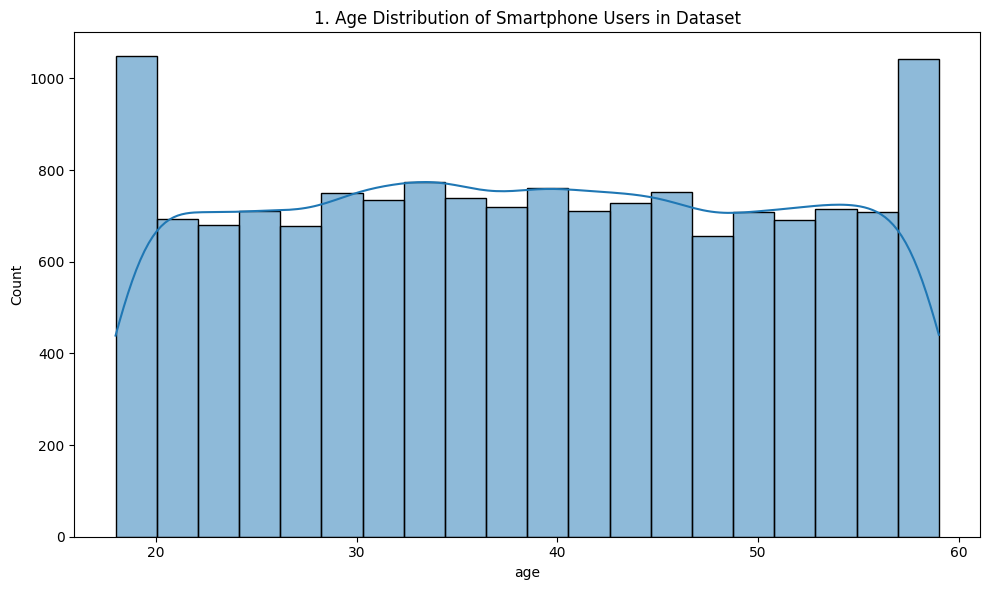

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['age'], bins=20, kde=True)
plt.title(f'{plot_no}. Age Distribution of Smartphone Users in Dataset')
show_fig()
plot_no += 1

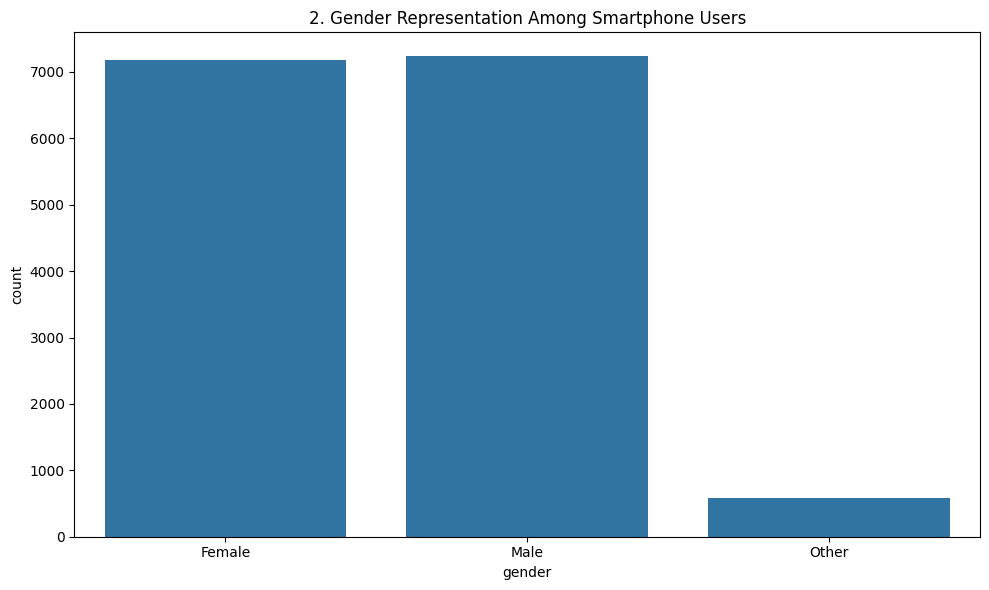

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='gender', data=df)
plt.title(f'{plot_no}. Gender Representation Among Smartphone Users')
show_fig()
plot_no += 1

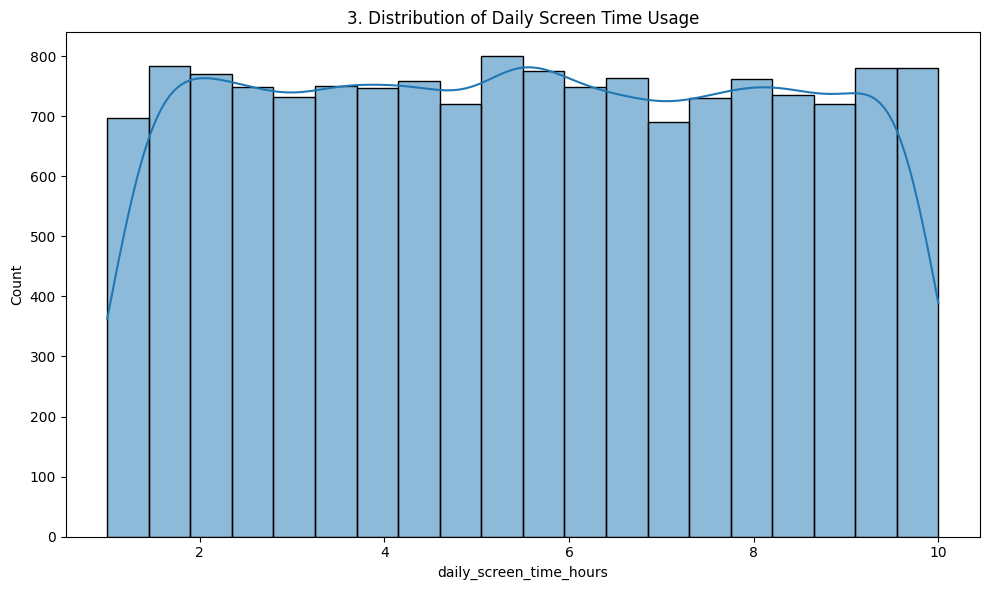

In [15]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['daily_screen_time_hours'], bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Daily Screen Time Usage')
show_fig()
plot_no += 1

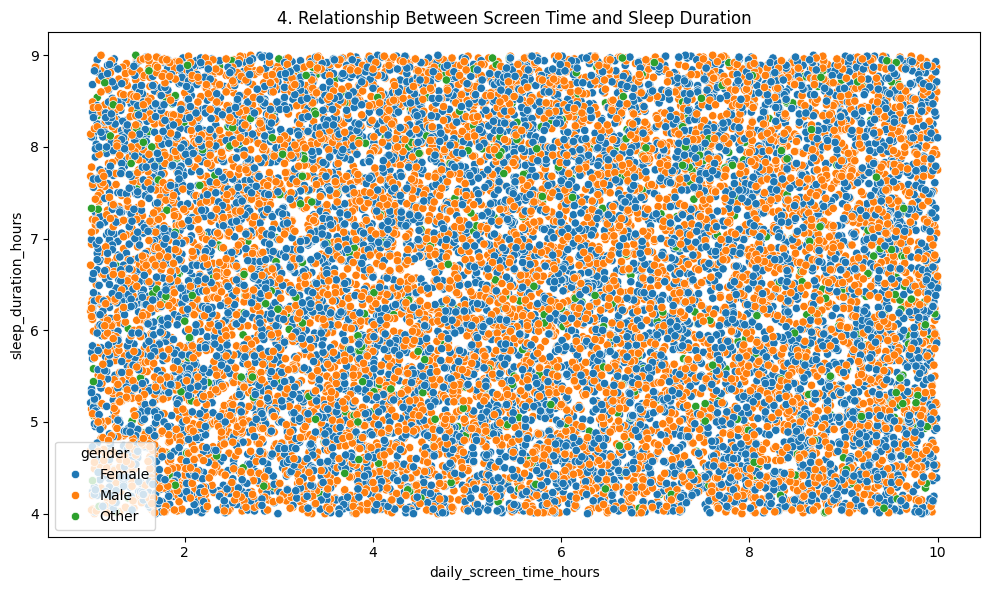

In [16]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='daily_screen_time_hours', y='sleep_duration_hours', hue='gender', data=df)
plt.title(f'{plot_no}. Relationship Between Screen Time and Sleep Duration')
show_fig()
plot_no += 1

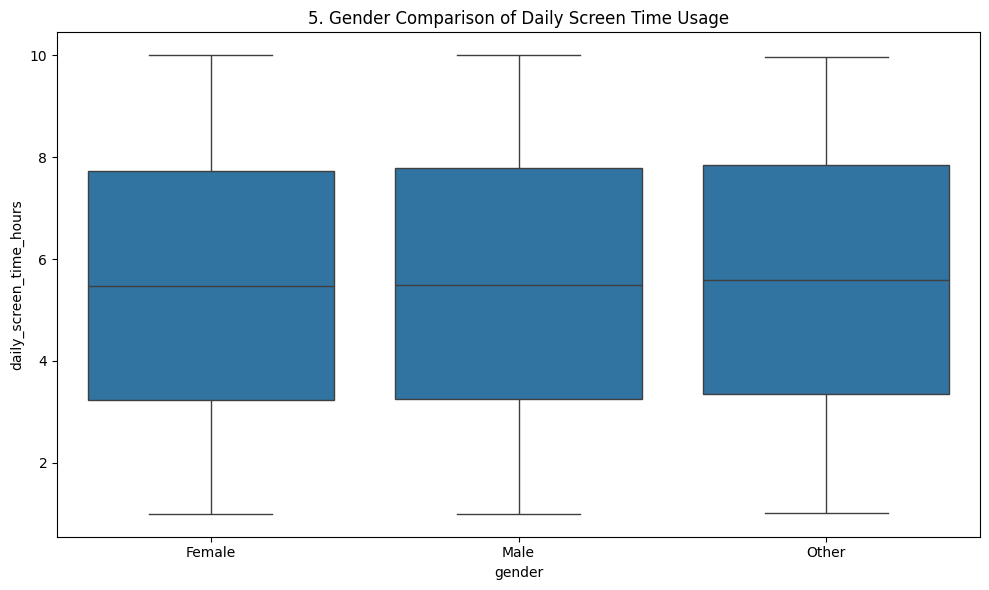

In [17]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='gender', y='daily_screen_time_hours', data=df)
plt.title(f'{plot_no}. Gender Comparison of Daily Screen Time Usage')
show_fig()
plot_no += 1

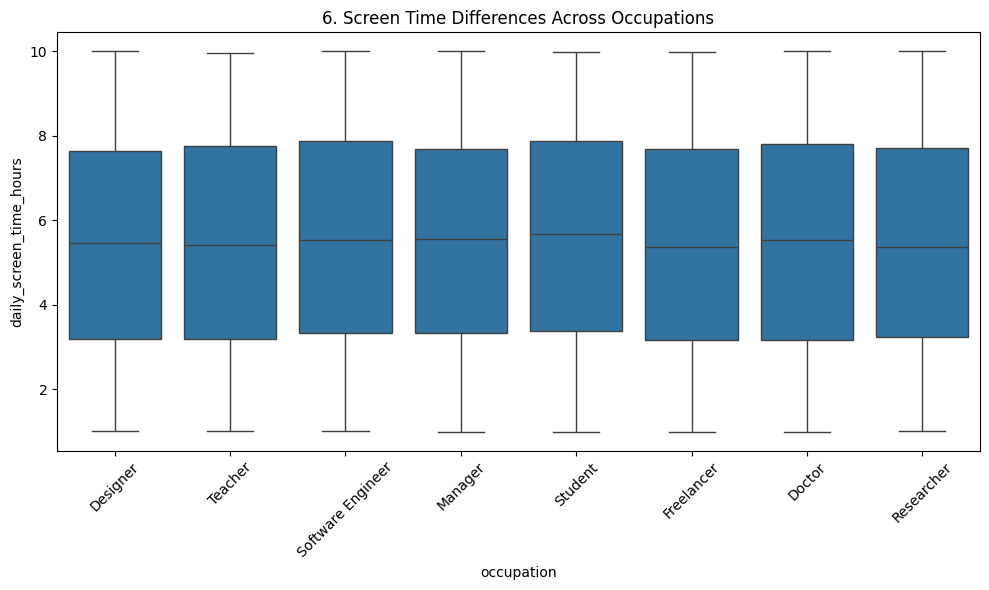

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='occupation', y='daily_screen_time_hours', data=df)
plt.title(f'{plot_no}. Screen Time Differences Across Occupations')
plt.xticks(rotation=45)
show_fig()
plot_no += 1

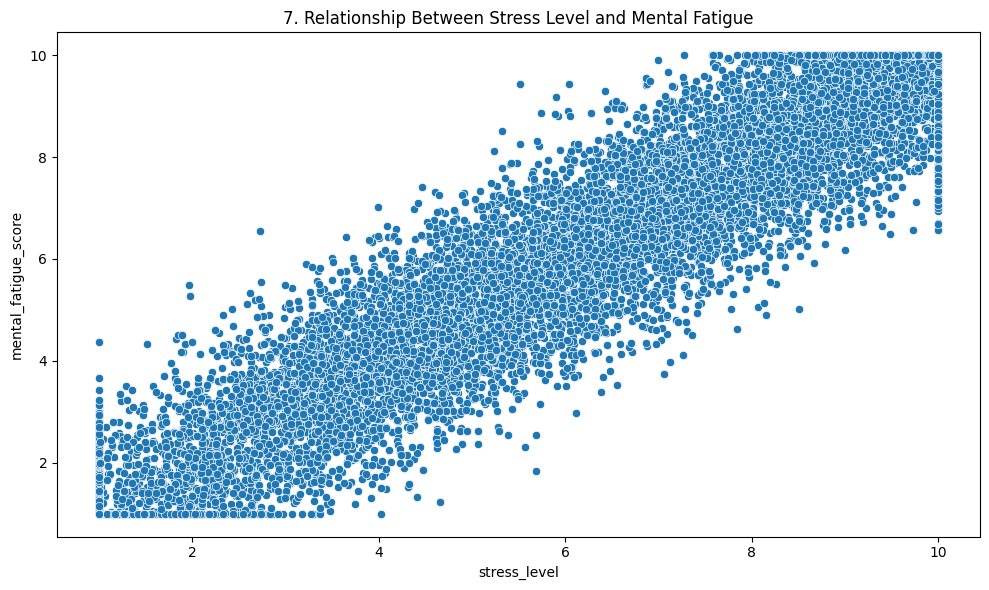

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='stress_level', y='mental_fatigue_score', data=df)
plt.title(f'{plot_no}. Relationship Between Stress Level and Mental Fatigue')
show_fig()
plot_no += 1

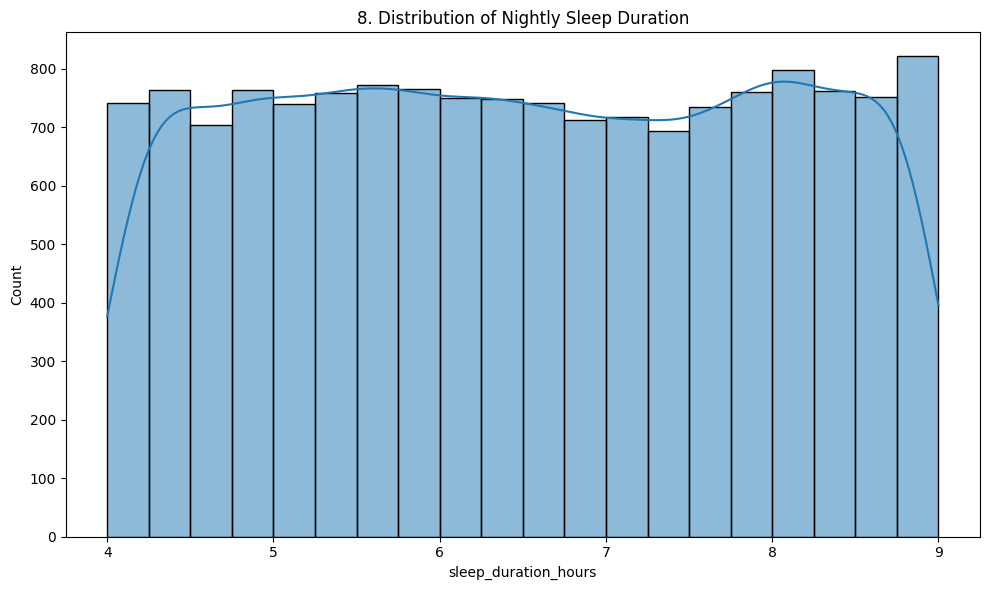

In [20]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['sleep_duration_hours'], bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Nightly Sleep Duration')
show_fig()
plot_no += 1

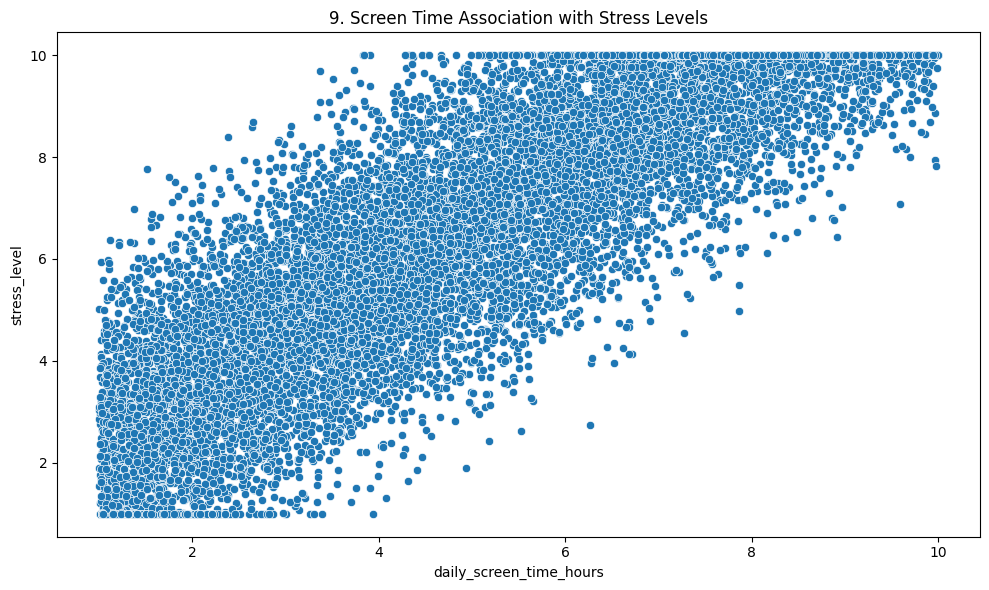

In [21]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='daily_screen_time_hours', y='stress_level', data=df)
plt.title(f'{plot_no}. Screen Time Association with Stress Levels')
show_fig()
plot_no += 1

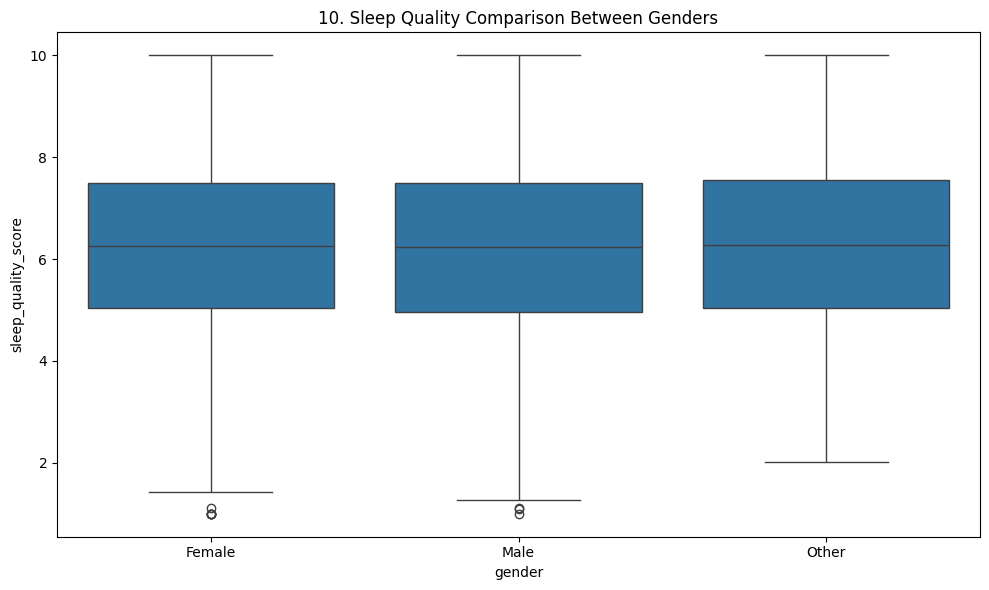

In [22]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='gender', y='sleep_quality_score', data=df)
plt.title(f'{plot_no}. Sleep Quality Comparison Between Genders')
show_fig()
plot_no += 1

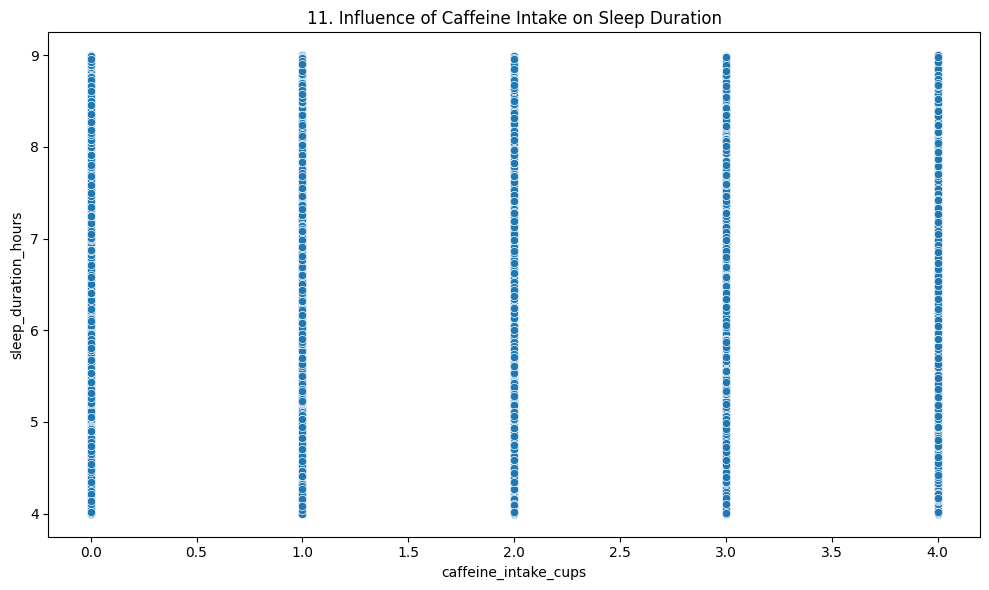

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='caffeine_intake_cups', y='sleep_duration_hours', data=df)
plt.title(f'{plot_no}. Influence of Caffeine Intake on Sleep Duration')
show_fig()
plot_no += 1

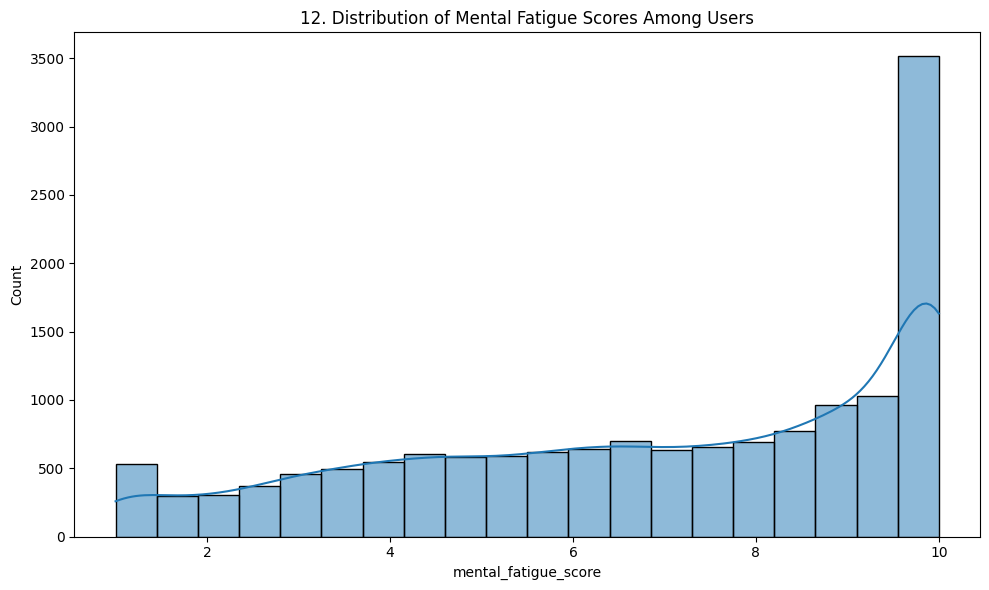

In [24]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['mental_fatigue_score'], bins=20, kde=True)
plt.title(f'{plot_no}. Distribution of Mental Fatigue Scores Among Users')
show_fig()
plot_no += 1

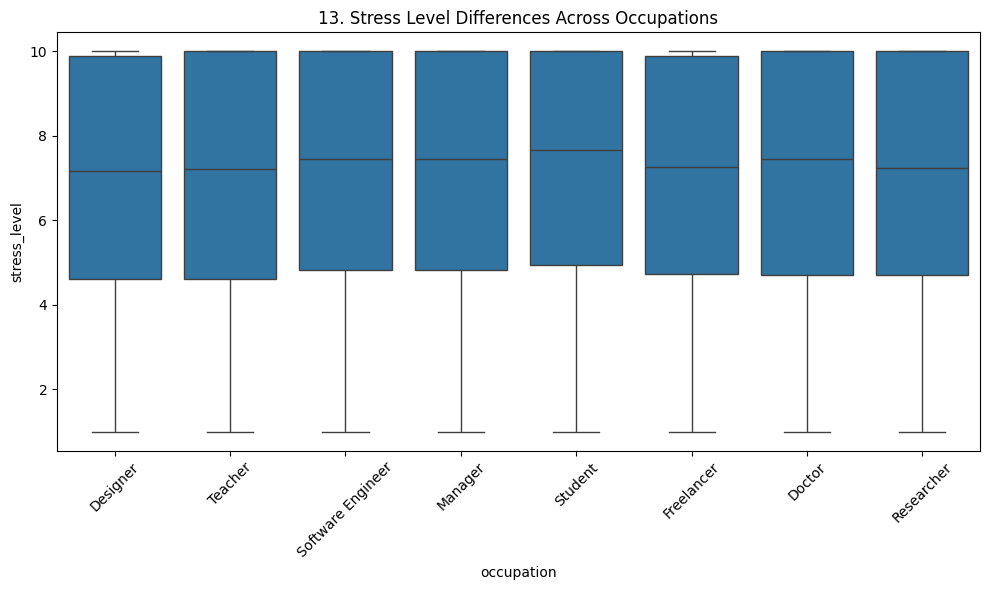

In [25]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='occupation', y='stress_level', data=df)
plt.title(f'{plot_no}. Stress Level Differences Across Occupations')
plt.xticks(rotation=45)
show_fig()
plot_no += 1

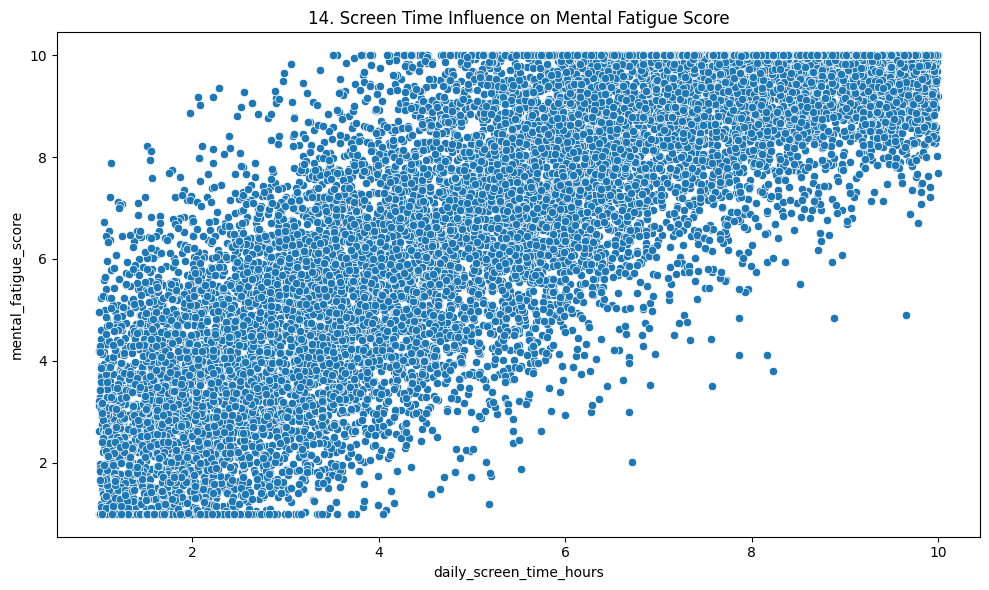

In [26]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='daily_screen_time_hours', y='mental_fatigue_score', data=df)
plt.title(f'{plot_no}. Screen Time Influence on Mental Fatigue Score')
show_fig()
plot_no += 1

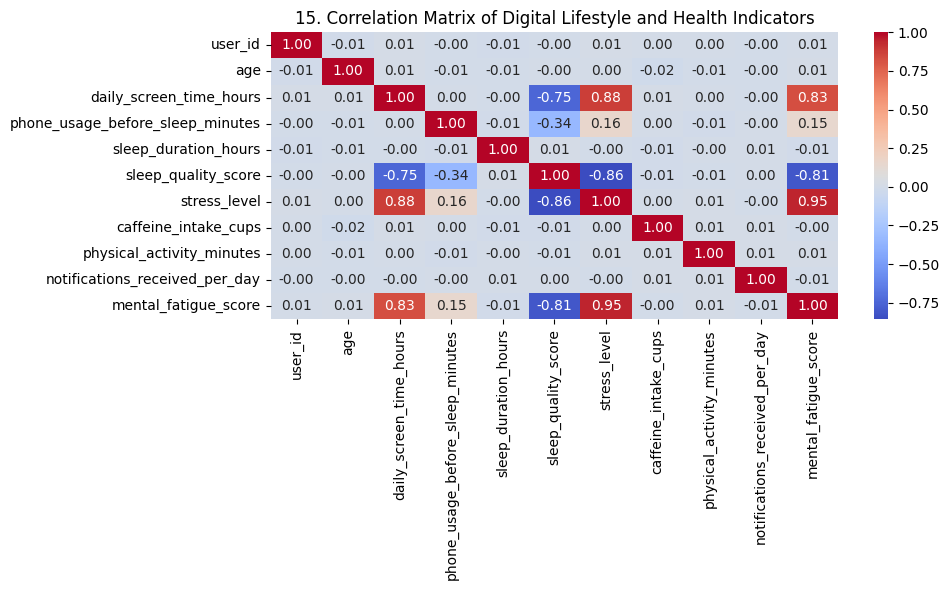

In [27]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Matrix of Digital Lifestyle and Health Indicators')
show_fig()
plot_no += 1

# Model Training

## Convert categorical columns into numeric using one-hot encoding

In [28]:
df_encoded = pd.get_dummies(df, drop_first=True)

## Create binary target variable from stress level

In [29]:
df_encoded['high_stress'] = (df_encoded['stress_level'] >= df_encoded['stress_level'].median()).astype(int)

## Define features and target

In [30]:
X = df_encoded.drop(columns=['user_id','high_stress'])
y = df_encoded['high_stress']

## Split dataset into training and testing

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## Apply feature scaling

In [32]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Train supervised Logistic Regression model

In [33]:
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

## Predict on test data

In [34]:
y_pred = model.predict(X_test)

## Print model accuracy

In [35]:
print("Model Accuracy:", accuracy_score(y_test,y_pred))

Model Accuracy: 0.993


## Plot confusion matrix

<Figure size 800x600 with 0 Axes>

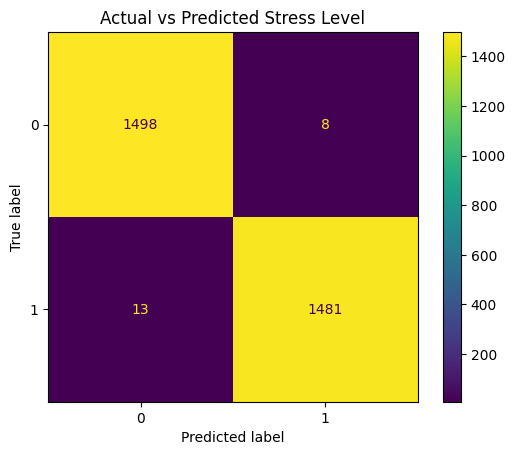

In [36]:
cm = confusion_matrix(y_test,y_pred)
fig = plt.figure(figsize=(8,6))
ConfusionMatrixDisplay(cm).plot()
plt.title("Actual vs Predicted Stress Level")
plt.show()